# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


## **Latar Belakang Dataset**

Dataset yang digunakan dalam proyek ini adalah **Customer Personality Analysis Dataset** yang diperoleh dari platform Kaggle. Dataset ini berisi informasi terkait karakteristik pelanggan, perilaku pembelian, serta respons pelanggan terhadap campaign marketing yang dilakukan oleh perusahaan.

Dataset ini digunakan untuk membangun model machine learning yang mampu memprediksi apakah seorang customer akan menerima campaign marketing atau tidak berdasarkan profil dan perilaku belanjanya.

## **Tujuan Proyek**

Tujuan utama dari proyek ini adalah membangun sistem machine learning untuk melakukan prediksi terhadap kolom target `Response`, yaitu apakah customer menerima campaign marketing.

Model yang dibangun nantinya diharapkan dapat membantu perusahaan dalam:

- Memahami karakteristik pelanggan.
- Mengidentifikasi pelanggan potensial.
- Mengoptimalkan strategi marketing campaign.
- Mengurangi biaya campaign yang tidak efektif.

## **Informasi Dataset**

- Nama Dataset: Customer Personality Analysis
- Sumber Dataset: Kaggle
- Format Dataset: CSV
- Nama File: `dataset_raw.csv`
- Jenis Dataset: Tabular Dataset
- Jenis Machine Learning: Classification
- Target Prediksi: `Response`



# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Library dasar
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Split dataset
from sklearn.model_selection import train_test_split

# Menghilangkan warning
import warnings
warnings.filterwarnings('ignore')

# Setting visualisasi
plt.style.use('ggplot')
sns.set_palette('Set2')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv('dataset_raw.csv', sep='\t')

# Menampilkan 5 data pertama
print("5 Data Pertama:")
display(df.head())

# Menampilkan jumlah baris dan kolom
print(f"Jumlah Baris dan Kolom: {df.shape}")

# Informasi dataset
print("\nInformasi Dataset:")
df.info()

# Statistik deskriptif
print("\nStatistik Deskriptif:")
display(df.describe())

5 Data Pertama:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


Jumlah Baris dan Kolom: (2240, 29)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-nul

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

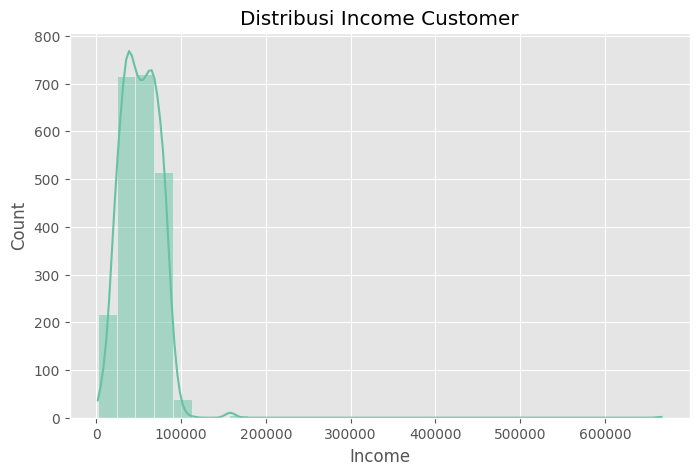

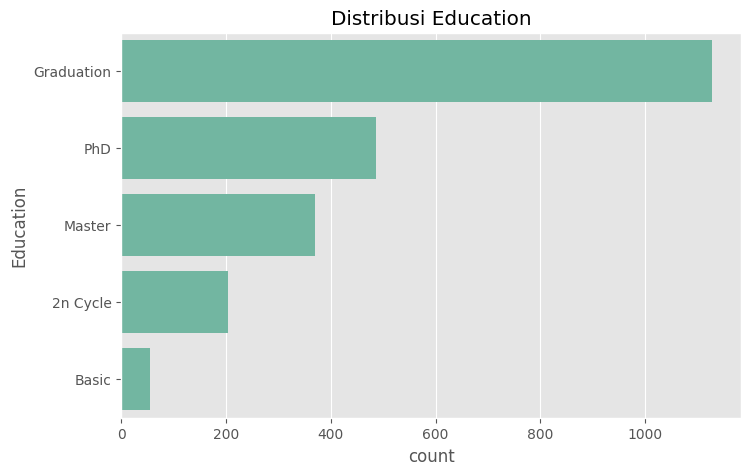

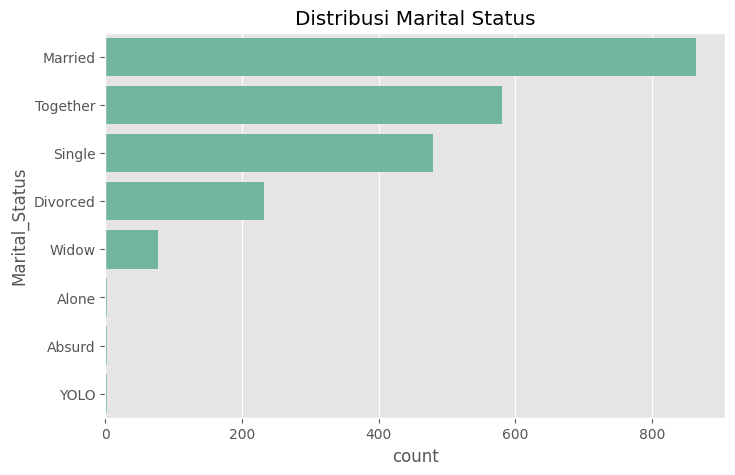

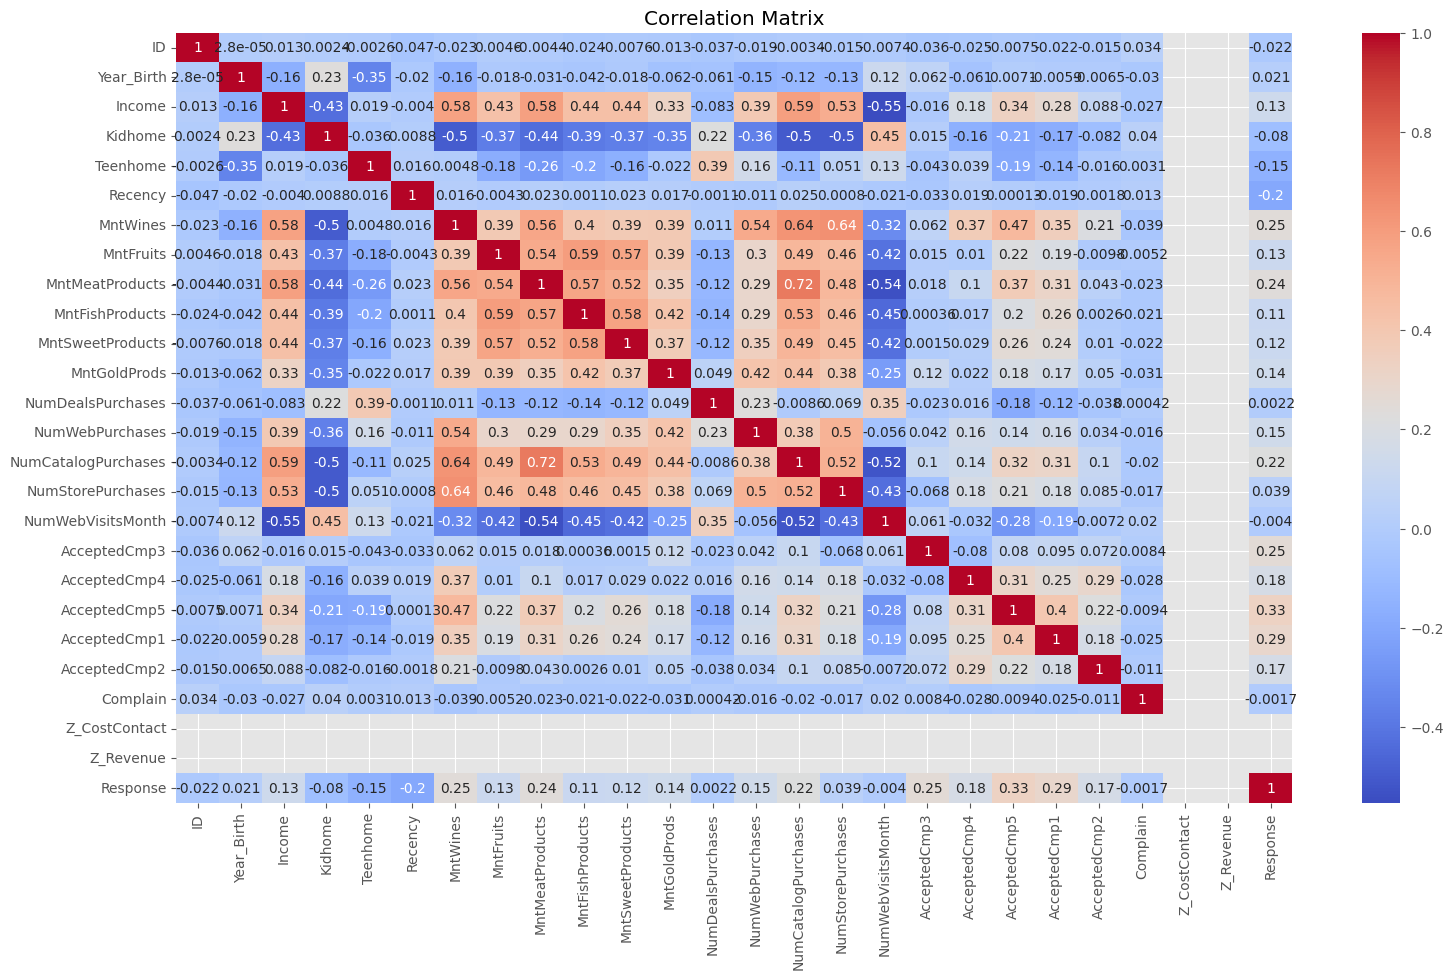

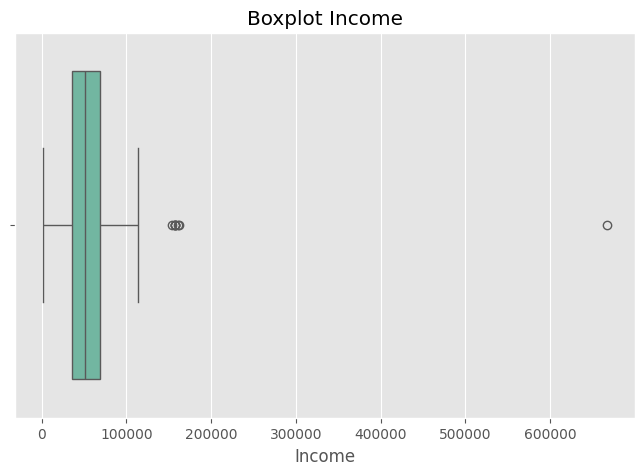

   Age  TotalSpending
0   68           1617
1   71             27
2   60            776
3   41             53
4   44            422


In [3]:
# Melihat nama kolom
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['Income'], bins=30, kde=True)
plt.title('Distribusi Income Customer')
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(y='Education', data=df, order=df['Education'].value_counts().index)
plt.title('Distribusi Education')
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(y='Marital_Status', data=df, order=df['Marital_Status'].value_counts().index)
plt.title('Distribusi Marital Status')
plt.show()

# =========================================
# Korelasi Antar Fitur Numerik
# =========================================

numeric_columns = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(18,10))
sns.heatmap(numeric_columns.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()



plt.figure(figsize=(8,5))
sns.boxplot(x=df['Income'])
plt.title('Boxplot Income')
plt.show()

# Membuat fitur umur
current_year = 2025

if 'Year_Birth' in df.columns:
    df['Age'] = current_year - df['Year_Birth']

# Total spending
spending_columns = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

existing_spending_cols = [col for col in spending_columns if col in df.columns]

if existing_spending_cols:
    df['TotalSpending'] = df[existing_spending_cols].sum(axis=1)

# Menampilkan hasil feature engineering
print(df[['Age', 'TotalSpending']].head())

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [5]:

preprocessing_df = df.copy()
if 'ID' in preprocessing_df.columns:
    preprocessing_df.drop(columns=['ID'], inplace=True)


# Mengisi missing value numerik dengan median
numeric_cols = preprocessing_df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    preprocessing_df[col].fillna(preprocessing_df[col].median(), inplace=True)

# Mengisi missing value kategorikal dengan modus
categorical_cols = preprocessing_df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    preprocessing_df[col].fillna(preprocessing_df[col].mode()[0], inplace=True)



label_encoder = LabelEncoder()

for col in categorical_cols:
    preprocessing_df[col] = label_encoder.fit_transform(preprocessing_df[col])



X = preprocessing_df.drop('Response', axis=1)
y = preprocessing_df['Response']



scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("Shape X Train:", X_train.shape)
print("Shape X Test:", X_test.shape)
print("Shape y Train:", y_train.shape)
print("Shape y Test:", y_test.shape)


processed_df = pd.DataFrame(X_scaled, columns=X.columns)
processed_df['Response'] = y.values

processed_df.to_csv('dataset_preprocessing.csv', index=False)

print("\nDataset preprocessing berhasil disimpan!")

Shape X Train: (1792, 29)
Shape X Test: (448, 29)
Shape y Train: (1792,)
Shape y Test: (448,)

Dataset preprocessing berhasil disimpan!
